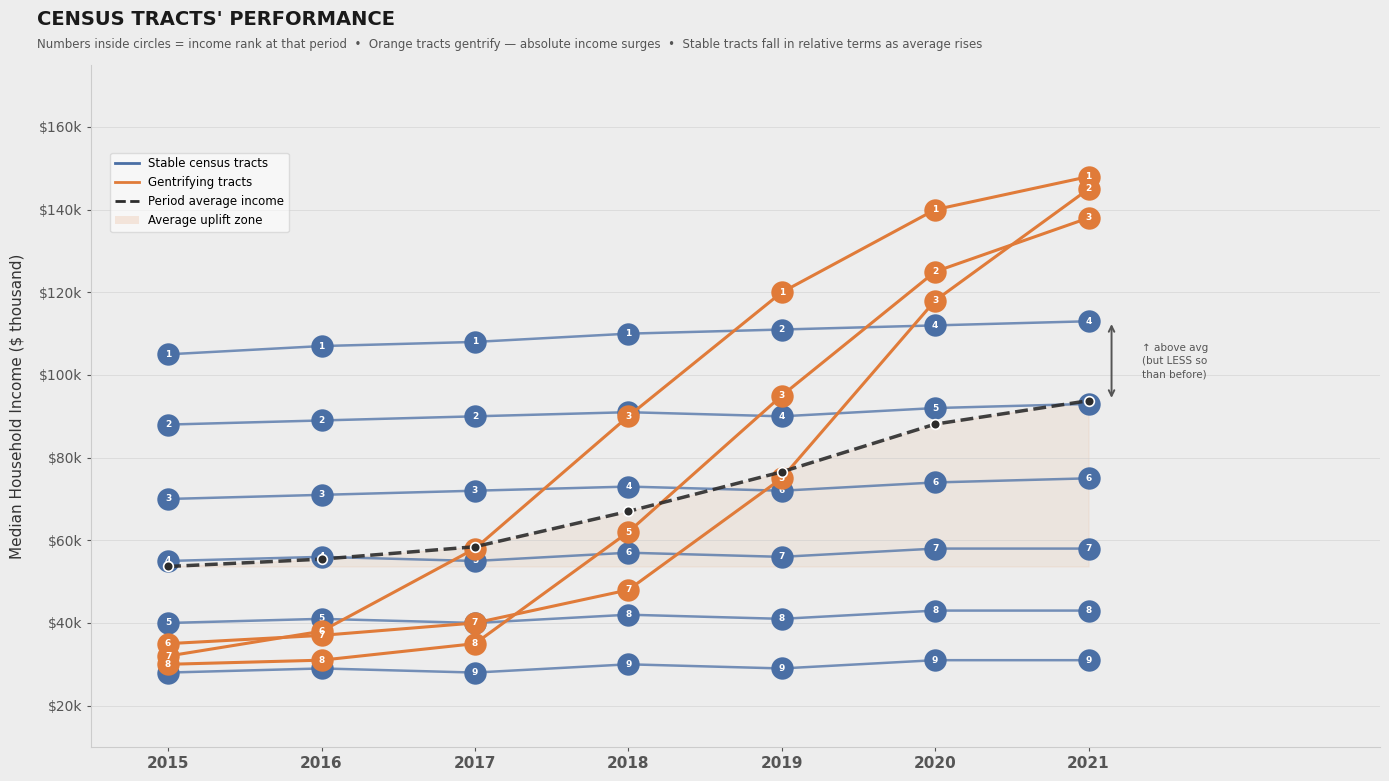

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Data design ──────────────────────────────────────────────────────────────
# 7 time periods
periods = ["2015", "2016", "2017", "2018", "2019", "2020", "2021"]

# 9 census tracts
# Stable tracts keep roughly the same absolute income
# Gentrifying tracts shoot up — they become the top earners
tracts = {
    "Tract 1 (stable, high)":   [105, 107, 108, 110, 111, 112, 113],
    "Tract 2 (stable, mid-hi)": [ 88,  89,  90,  91,  90,  92,  93],
    "Tract 3 (stable, mid)":    [ 70,  71,  72,  73,  72,  74,  75],
    "Tract 4 (stable, mid-lo)": [ 55,  56,  55,  57,  56,  58,  58],
    "Tract 5 (stable, low)":    [ 40,  41,  40,  42,  41,  43,  43],
    "Tract 6 (stable, lowest)": [ 28,  29,  28,  30,  29,  31,  31],
    # ── Gentrifiers ──
    "Tract G1 (gentrify early)":[ 32,  38,  58,  90, 120, 140, 148],
    "Tract G2 (gentrify late)": [ 35,  37,  40,  48,  75, 118, 145],
    "Tract G3 (gentrify mid)":  [ 30,  31,  35,  62,  95, 125, 138],
}

# Colour palette: stable = slate-blue, gentrifying = orange, average = dark
STABLE_COLOR   = "#4A6FA5"   # muted navy blue
GENTRIFY_COLOR = "#E07B39"   # warm orange
AVERAGE_COLOR  = "#2C2C2C"   # near-black

def is_gentrify(name):
    return "gentrify" in name.lower()

# ── Compute average per period ────────────────────────────────────────────────
incomes_array = np.array(list(tracts.values()))          # shape (9, 7)
average = incomes_array.mean(axis=0)

# ── Figure setup ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("#EDEDED")
ax.set_facecolor("#EDEDED")

x = np.arange(len(periods))

# ── Draw tract lines ──────────────────────────────────────────────────────────
for name, income in tracts.items():
    gen    = is_gentrify(name)
    color  = GENTRIFY_COLOR if gen else STABLE_COLOR
    lw     = 2.2 if gen else 1.8
    zorder = 4 if gen else 3
    alpha  = 1.0 if gen else 0.75

    y = np.array(income)
    ax.plot(x, y, color=color, linewidth=lw, zorder=zorder,
            alpha=alpha, solid_capstyle="round")

    # Dot markers with rank-number inside (rank by income descending each period)
    for i, (xi, yi) in enumerate(zip(x, y)):
        # Compute rank at this period
        snapshot = {k: v[i] for k, v in tracts.items()}
        sorted_names = sorted(snapshot, key=lambda k: snapshot[k], reverse=True)
        rank = sorted_names.index(name) + 1

        # Use scatter so marker size is in points² (display space) — stays circular
        ax.scatter(xi, yi, s=260, color=color, zorder=zorder + 1,
                   linewidths=0)
        ax.text(xi, yi, str(rank), ha="center", va="center",
                fontsize=6.5, fontweight="bold", color="white",
                zorder=zorder + 2)

# ── Average line ──────────────────────────────────────────────────────────────
ax.plot(x, average, color=AVERAGE_COLOR, linewidth=2.5,
        linestyle="--", zorder=6, alpha=0.9, label="Period average")

for xi, yi in zip(x, average):
    ax.plot(xi, yi, "o", color=AVERAGE_COLOR, markersize=7,
            zorder=7, markeredgecolor="white", markeredgewidth=1.2)

# ── Annotations: show relative decline for a stable tract ────────────────────
# Pick Tract 1 (highest stable) — show gap between it and average
y1_first = tracts["Tract 1 (stable, high)"][0]
y1_last  = tracts["Tract 1 (stable, high)"][-1]
avg_last = average[-1]

# Bracket showing distance of Tract 1 from average at end
ax.annotate("",
            xy=(x[-1] + 0.15, avg_last),
            xytext=(x[-1] + 0.15, y1_last),
            arrowprops=dict(arrowstyle="<->", color="#555555", lw=1.4))
ax.text(x[-1] + 0.35, (avg_last + y1_last) / 2,
        f"↑ above avg\n(but LESS so\nthan before)",
        va="center", ha="left", fontsize=7.5, color="#555555",
        linespacing=1.4)

# Shaded region showing average rise driven by gentrifiers
ax.fill_between(x, average[0], average,
                alpha=0.08, color=GENTRIFY_COLOR, zorder=1,
                label="Rising average (gentrification effect)")

# ── Axis formatting ───────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=11, fontweight="bold", color="#333333")
ax.set_xlim(-0.5, len(periods) - 0.5 + 1.4)   # extra room for annotation
ax.set_ylim(10, 175)
ax.set_ylabel("Median Household Income ($ thousand)", fontsize=11,
              color="#333333", labelpad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}k"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#555555", length=3)
ax.yaxis.tick_left()
ax.grid(axis="y", color="#CCCCCC", linewidth=0.6, linestyle="-", alpha=0.6)

# ── Title & subtitle ──────────────────────────────────────────────────────────
fig.text(0.03, 0.97, "CENSUS TRACTS' PERFORMANCE",
         fontsize=14, fontweight="bold", color="#1A1A1A",
         va="top", ha="left")
fig.text(0.03, 0.935,
         "Numbers inside circles = income rank at that period  •  "
         "Orange tracts gentrify — absolute income surges  •  "
         "Stable tracts fall in relative terms as average rises",
         fontsize=8.5, color="#555555", va="top", ha="left")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=STABLE_COLOR,   linewidth=2, label="Stable census tracts"),
    Line2D([0], [0], color=GENTRIFY_COLOR, linewidth=2, label="Gentrifying tracts"),
    Line2D([0], [0], color=AVERAGE_COLOR,  linewidth=2,
           linestyle="--", label="Period average income"),
    mpatches.Patch(facecolor=GENTRIFY_COLOR, alpha=0.15,
                   label="Average uplift zone"),
]
ax.legend(handles=legend_elements, loc="upper left",
          fontsize=8.5, framealpha=0.6, edgecolor="#CCCCCC",
          bbox_to_anchor=(0.01, 0.88))

plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.savefig("/mnt/user-data/outputs/gentrification_chart.png",
#             dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
# print("Saved.")
# plt.close()

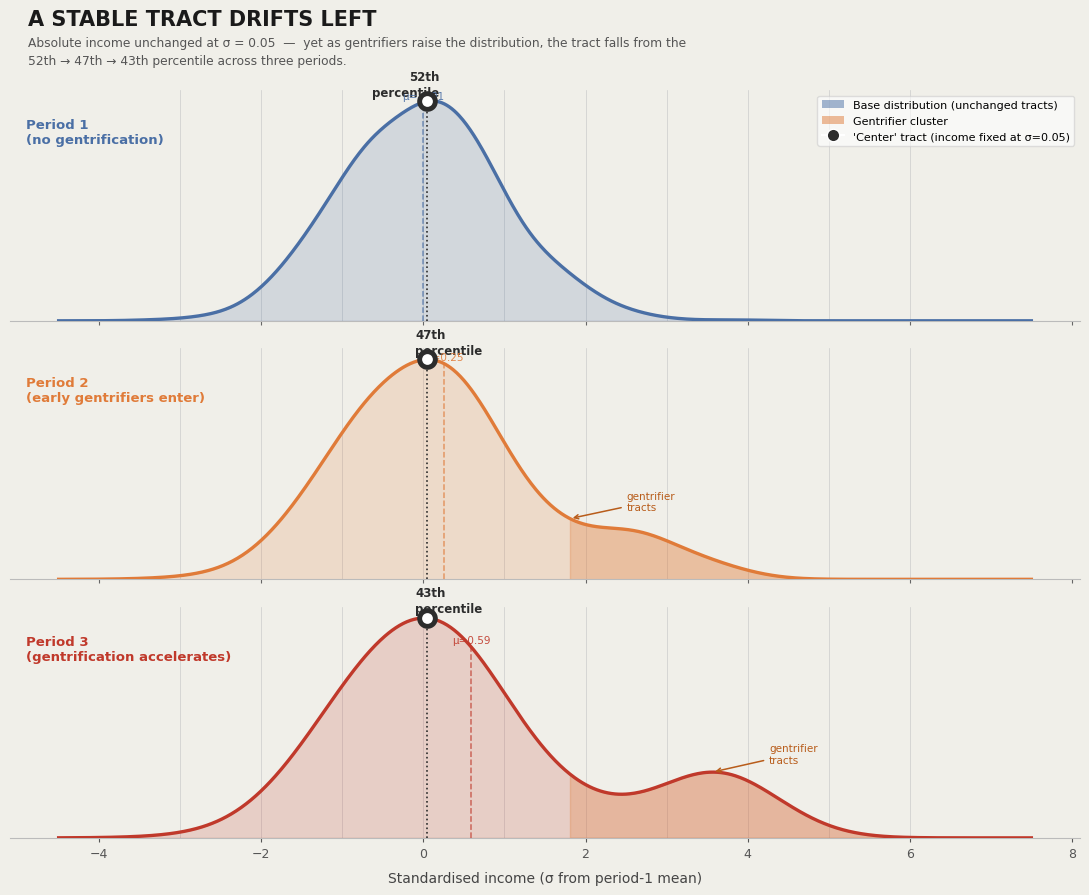

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from scipy import stats

np.random.seed(42)

# ── Data generation ───────────────────────────────────────────────────────────
N_BASE = 800   # base population of tracts

# Period 1: pure N(0,1) — no gentrification yet
base   = np.random.normal(0, 1, N_BASE)
p1     = base.copy()

# Period 2: same base + a cluster of early gentrifiers emerging high end
n_g2       = 80
gentrifiers2 = np.random.normal(2.8, 0.5, n_g2)
p2         = np.concatenate([base, gentrifiers2])

# Period 3: same base + more & further gentrifiers
n_g3       = 160
gentrifiers3 = np.random.normal(3.5, 0.55, n_g3)
p3         = np.concatenate([base, gentrifiers3])

periods    = [p1, p2, p3]
labels     = ["Period 1\n(no gentrification)",
              "Period 2\n(early gentrifiers enter)",
              "Period 3\n(gentrification accelerates)"]

# ── The "center" tract — absolute income unchanged ────────────────────────────
CENTER_TRACT_VALUE = 0.05   # fixed, does not move

# ── Style ─────────────────────────────────────────────────────────────────────
COLORS   = ["#4A6FA5", "#E07B39", "#C0392B"]   # blue → orange → red
BG_COLOR = "#F0EFE9"
FILL_ALPHA = 0.18
LW       = 2.4

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.patch.set_facecolor(BG_COLOR)

x_grid = np.linspace(-4.5, 7.5, 800)

all_percentiles = []

for ax, data, label, color, period_idx in zip(axes, periods, labels, COLORS, range(3)):
    ax.set_facecolor(BG_COLOR)

    # ── KDE curve ────────────────────────────────────────────────────────────
    kde  = gaussian_kde(data, bw_method=0.35)
    dens = kde(x_grid)

    ax.plot(x_grid, dens, color=color, linewidth=LW, zorder=3)
    ax.fill_between(x_grid, dens, alpha=FILL_ALPHA, color=color, zorder=2)

    # ── Shade gentrifier tail (period 2+) ────────────────────────────────────
    if period_idx > 0:
        mask = x_grid > 1.8
        ax.fill_between(x_grid[mask], dens[mask], alpha=0.28,
                        color="#E07B39", zorder=2,
                        label="Gentrifier cluster" if period_idx == 1 else None)
        # small annotation arrow pointing at the bump
        peak_x = x_grid[mask][np.argmax(dens[mask])]
        peak_y = dens[mask].max()
        ax.annotate("gentrifier\ntracts",
                    xy=(peak_x, peak_y),
                    xytext=(peak_x + 0.7, peak_y + 0.01),
                    fontsize=7.5, color="#B85C1A",
                    arrowprops=dict(arrowstyle="->", color="#B85C1A", lw=1.1),
                    va="bottom", ha="left")

    # ── Compute percentile of center tract in this period ─────────────────────
    pct = stats.percentileofscore(data, CENTER_TRACT_VALUE, kind="rank")
    all_percentiles.append(pct)

    # Height of KDE at center tract value
    marker_y = float(kde(np.array([CENTER_TRACT_VALUE]))[0])

    # Vertical dashed drop-line from marker to x-axis
    ax.plot([CENTER_TRACT_VALUE, CENTER_TRACT_VALUE], [0, marker_y],
            color="#2C2C2C", linewidth=1.2, linestyle=":", zorder=4)

    # Marker dot (scatter keeps it circular)
    ax.scatter(CENTER_TRACT_VALUE, marker_y, s=220, color="#2C2C2C",
               zorder=6, linewidths=0)
    ax.scatter(CENTER_TRACT_VALUE, marker_y, s=60, color="white",
               zorder=7, linewidths=0)

    # Percentile label beside marker
    pct_dir = "left" if period_idx > 0 else "right"
    offset  = -0.15 if period_idx > 0 else 0.15
    ax.text(CENTER_TRACT_VALUE + offset, marker_y + 0.004,
            f"{pct:.0f}th\npercentile",
            ha=pct_dir, va="bottom", fontsize=8.5, color="#2C2C2C",
            fontweight="bold", linespacing=1.3)

    # Mean of distribution
    mean_val = data.mean()
    mean_y   = float(kde(np.array([mean_val]))[0])
    ax.plot([mean_val, mean_val], [0, mean_y],
            color=color, linewidth=1.1, linestyle="--", alpha=0.7, zorder=3)
    ax.text(mean_val, mean_y + 0.003, f"μ={mean_val:.2f}",
            ha="center", va="bottom", fontsize=7.5, color=color, alpha=0.9)

    # ── Panel label ───────────────────────────────────────────────────────────
    ax.text(0.015, 0.88, label, transform=ax.transAxes,
            fontsize=9.5, fontweight="bold", color=color,
            va="top", ha="left")

    # ── Axes cosmetics ────────────────────────────────────────────────────────
    ax.set_ylim(bottom=0)
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#BBBBBB")
    ax.tick_params(colors="#666666", length=3)

    # Light vertical grid only
    for v in [-3, -2, -1, 0, 1, 2, 3, 4, 5, 6]:
        ax.axvline(v, color="#CCCCCC", linewidth=0.5, zorder=1)

# ── Shared x-axis label ───────────────────────────────────────────────────────
axes[-1].set_xlabel("Standardised income (σ from period-1 mean)",
                    fontsize=10, color="#444444", labelpad=8)
axes[-1].tick_params(axis="x", labelsize=9, colors="#555555")

# ── Title & subtitle ──────────────────────────────────────────────────────────
fig.text(0.03, 0.99, "A STABLE TRACT DRIFTS LEFT",
         fontsize=15, fontweight="bold", color="#1A1A1A", va="top")
fig.text(0.03, 0.96,
         "Absolute income unchanged at σ = 0.05  —  yet as gentrifiers raise "
         "the distribution, the tract falls from the\n"
         f"{all_percentiles[0]:.0f}th → "
         f"{all_percentiles[1]:.0f}th → "
         f"{all_percentiles[2]:.0f}th percentile across three periods.",
         fontsize=8.8, color="#555555", va="top", linespacing=1.5)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor="#4A6FA5", alpha=0.5, label="Base distribution (unchanged tracts)"),
    mpatches.Patch(facecolor="#E07B39", alpha=0.5, label="Gentrifier cluster"),
    Line2D_proxy := plt.Line2D([0], [0], marker="o", color="w",
                               markerfacecolor="#2C2C2C", markersize=9,
                               label="'Center' tract (income fixed at σ=0.05)"),
]
axes[0].legend(handles=legend_elements, loc="upper right",
               fontsize=8, framealpha=0.6, edgecolor="#CCCCCC")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.subplots_adjust(hspace=0.12)
# plt.savefig("/mnt/user-data/outputs/kde_gentrification.png",
#             dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
# print("Saved.")
# plt.close()

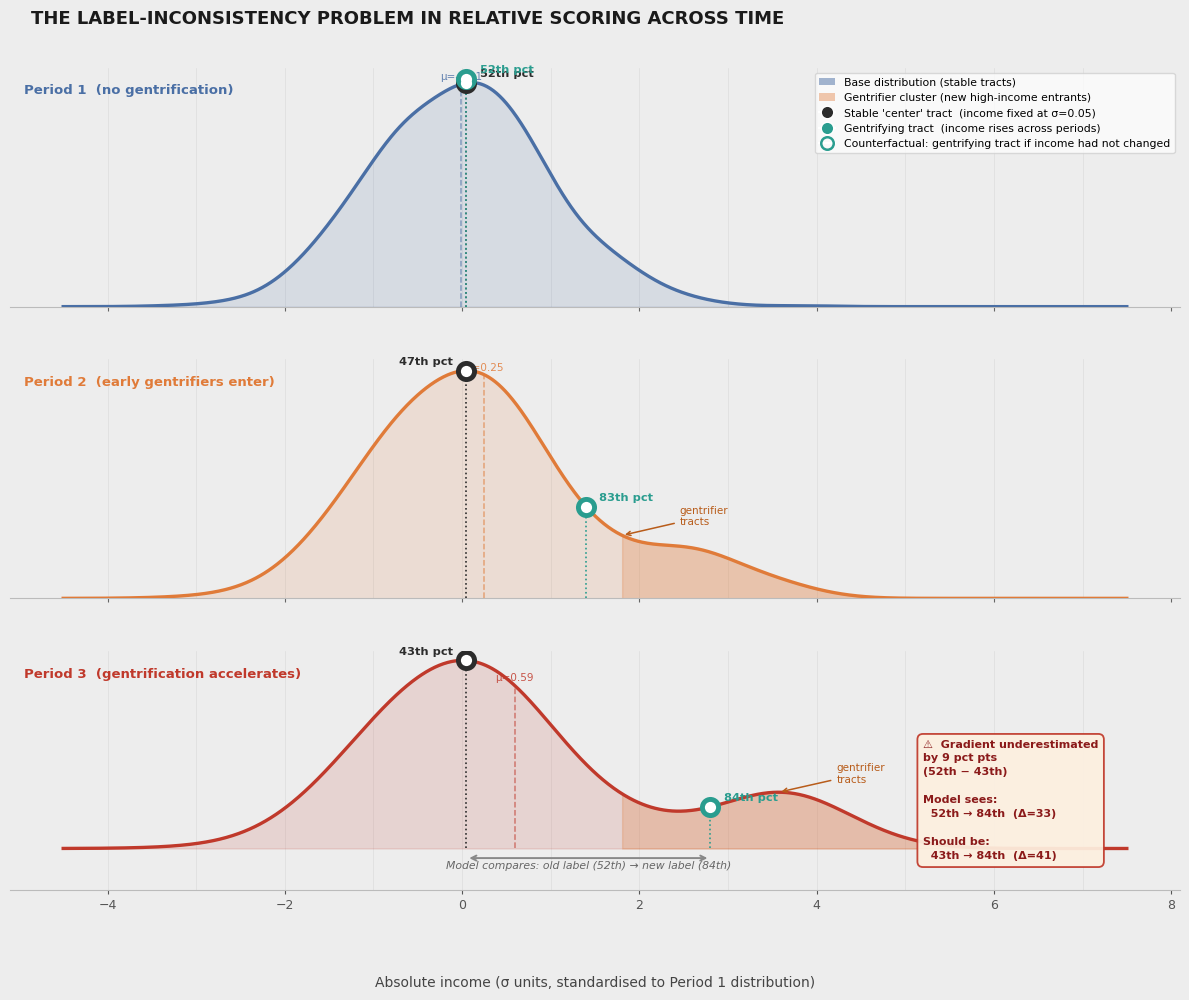

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from scipy import stats

np.random.seed(42)

# ── Data generation ───────────────────────────────────────────────────────────
N_BASE = 800

base = np.random.normal(0, 1, N_BASE)
p1   = base.copy()
p2   = np.concatenate([base, np.random.normal(2.8, 0.5, 80)])
p3   = np.concatenate([base, np.random.normal(3.5, 0.55, 160)])

periods = [p1, p2, p3]
labels  = ["Period 1  (no gentrification)",
           "Period 2  (early gentrifiers enter)",
           "Period 3  (gentrification accelerates)"]

# ── Tract definitions ─────────────────────────────────────────────────────────
# Stable tract — income never changes
CENTER = 0.05

# Gentrifying tract — starts at SAME position as center in P1 ("old label" = ~52nd pct),
# then rises sharply in absolute income
GENTRY_P1 = 0.05   # same as center → old label = ~52nd pct
GENTRY_P2 = 1.40
GENTRY_P3 = 2.80
GENTRY_INCOME = [GENTRY_P1, GENTRY_P2, GENTRY_P3]

# ── Style ─────────────────────────────────────────────────────────────────────
CURVE_COLORS  = ["#4A6FA5", "#E07B39", "#C0392B"]
CENTER_COLOR  = "#2C2C2C"
GENTRY_COLOR  = "#2A9D8F"
BG_COLOR      = "#EDEDED"
LW = 2.4

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.patch.set_facecolor(BG_COLOR)
x_grid = np.linspace(-4.5, 7.5, 1000)

center_pcts = []
gentry_pcts = []

for ax, data, label, color, pidx in zip(axes, periods, labels, CURVE_COLORS, range(3)):
    ax.set_facecolor(BG_COLOR)

    kde  = gaussian_kde(data, bw_method=0.35)
    dens = kde(x_grid)

    # KDE fill & curve
    ax.fill_between(x_grid, dens, alpha=0.14, color=color, zorder=2)
    ax.plot(x_grid, dens, color=color, linewidth=LW, zorder=3)

    # Shade gentrifier tail
    if pidx > 0:
        mask = x_grid > 1.8
        ax.fill_between(x_grid[mask], dens[mask], alpha=0.25, color="#E07B39", zorder=2)
        peak_x = x_grid[mask][np.argmax(dens[mask])]
        peak_y = dens[mask].max()
        ax.annotate("gentrifier\ntracts",
                    xy=(peak_x, peak_y), xytext=(peak_x + 0.65, peak_y + 0.012),
                    fontsize=7.5, color="#B85C1A",
                    arrowprops=dict(arrowstyle="->", color="#B85C1A", lw=1.1),
                    va="bottom", ha="left")

    # Mean line
    mu   = data.mean()
    mu_y = float(kde(np.array([mu]))[0])
    ax.plot([mu, mu], [0, mu_y], color=color, lw=1.1, linestyle="--", alpha=0.6, zorder=3)
    ax.text(mu, mu_y + 0.003, f"μ={mu:.2f}",
            ha="center", va="bottom", fontsize=7.5, color=color, alpha=0.85)

    # Helper: draw a circular marker with percentile label
    def draw_marker(x_val, mcolor, side="right", y_nudge=0):
        pct  = stats.percentileofscore(data, x_val, kind="rank")
        mk_y = float(kde(np.array([x_val]))[0])
        ax.plot([x_val, x_val], [0, mk_y], color=mcolor, lw=1.2,
                linestyle=":", zorder=4)
        ax.scatter(x_val, mk_y + y_nudge, s=230, color=mcolor, zorder=6, linewidths=0)
        ax.scatter(x_val, mk_y + y_nudge, s=65,  color="white", zorder=7, linewidths=0)
        ha  = "left" if side == "right" else "right"
        off = 0.15 if side == "right" else -0.15
        ax.text(x_val + off, mk_y + 0.006 + y_nudge,
                f"{pct:.0f}th pct",
                ha=ha, va="bottom", fontsize=8.2, color=mcolor,
                fontweight="bold")
        return pct

    # CENTER (stable) tract
    cpct = draw_marker(CENTER, CENTER_COLOR, side="left" if pidx > 0 else "right")
    center_pcts.append(cpct)

    # GENTRIFYING tract (slightly offset y so markers don't overlap in P1)
    g_income = GENTRY_INCOME[pidx]
    gpct     = draw_marker(g_income, GENTRY_COLOR,
                           side="right", y_nudge=0.007 if pidx == 0 else 0)
    gentry_pcts.append(gpct)

    # ── Period 3: the key annotation explaining the gradient problem ──────────
    if pidx == 2:
        old_label_pct    = center_pcts[0]    # ~52 — gentrifying tract's P1 label
        counterfact_pct  = center_pcts[2]    # ~43 — where it would be if unchanged

        bx1, bx2 = GENTRY_P1, GENTRY_P3
        by_base  = -0.010

        # Ghost (hollow) marker at counterfactual position
        # cf_y = float(kde(np.array([GENTRY_P1]))[0])
        # ax.scatter(GENTRY_P1, cf_y, s=200, zorder=5, linewidths=1.8,
        #            facecolors="none", edgecolors=GENTRY_COLOR)
        # ax.text(GENTRY_P1 - 0.18, cf_y + 0.013,
        #         f"counterfactual\n({counterfact_pct:.0f}th pct)",
        #         ha="right", va="bottom", fontsize=7.8, color=GENTRY_COLOR,
        #         fontstyle="italic", linespacing=1.3)

        # Bracket A — what the model does: old label → new label
        by_a = by_base - 0.005
        ax.annotate("", xy=(bx2, by_a), xytext=(bx1, by_a),
                    arrowprops=dict(arrowstyle="<->", color="#888888",
                                   lw=1.4, mutation_scale=9),
                    annotation_clip=False)
        ax.text((bx1 + bx2) / 2, by_a - 0.004,
                f"Model compares: old label ({old_label_pct:.0f}th) → new label ({gpct:.0f}th)",
                ha="center", va="top", fontsize=7.8, color="#666666",
                fontstyle="italic")

        # Bracket B — what should be compared: counterfactual → new label
        # by_b = by_base - 0.022
        # ax.annotate("", xy=(bx2, by_b), xytext=(bx1, by_b),
        #             arrowprops=dict(arrowstyle="<->", color=GENTRY_COLOR,
        #                            lw=1.6, mutation_scale=9),
        #             annotation_clip=False)
        # ax.text((bx1 + bx2) / 2, by_b - 0.004,
        #         f"True comparison: counterfactual ({counterfact_pct:.0f}th) → actual ({gpct:.0f}th)",
        #         ha="center", va="top", fontsize=7.8, color=GENTRY_COLOR,
        #         fontweight="bold")

        # Warning box showing underestimation
        n_underest = old_label_pct - counterfact_pct
        ax.text(5.2, 0.075,
                f"⚠  Gradient underestimated\n"
                f"by {n_underest:.0f} pct pts\n"
                f"({old_label_pct:.0f}th − {counterfact_pct:.0f}th)\n\n"
                f"Model sees:\n  {old_label_pct:.0f}th → {gpct:.0f}th  (Δ={gpct-old_label_pct:.0f})\n\n"
                f"Should be:\n  {counterfact_pct:.0f}th → {gpct:.0f}th  (Δ={gpct-counterfact_pct:.0f})",
                ha="left", va="center", fontsize=8, color="#8B1A1A",
                fontweight="bold", linespacing=1.5,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#FDF0E0",
                          edgecolor="#C0392B", linewidth=1.3, alpha=0.93))

    # Panel label
    ax.text(0.012, 0.93, label, transform=ax.transAxes,
            fontsize=9.5, fontweight="bold", color=color, va="top")

    # Axes cosmetics
    ax.set_ylim(bottom=-0.065 if pidx == 2 else 0)
    ax.set_yticks([])
    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color("#BBBBBB")
    ax.tick_params(colors="#666666", length=3)
    for v in range(-4, 8):
        ax.axvline(v, color="#DDDDDD", linewidth=0.5, zorder=1)

axes[-1].set_xlabel("Absolute income (σ units, standardised to Period 1 distribution)",
                    fontsize=10, color="#444444", labelpad=46)
axes[-1].tick_params(axis="x", labelsize=9, colors="#555555")

# Title & subtitle
fig.text(0.03, 0.995,
         "THE LABEL-INCONSISTENCY PROBLEM IN RELATIVE SCORING ACROSS TIME",
         fontsize=13, fontweight="bold", color="#1A1A1A", va="top")
# fig.text(0.03, 0.965,
#          f"Stable tract: {center_pcts[0]:.0f}th → {center_pcts[2]:.0f}th pct  (income fixed — falls in relative terms as distribution shifts right)\n"
#          f"Gentrifying tract: starts at same position as stable tract (old label = {gentry_pcts[0]:.0f}th pct), rises to {gentry_pcts[2]:.0f}th pct by P3.\n",
#         #  f"The model anchors to the old label ({center_pcts[0]:.0f}th) instead of the P3 counterfactual ({center_pcts[2]:.0f}th), "
#         #  f"systematically underestimating the gentrification gradient.",
#          fontsize=8.6, color="#555555", va="top", linespacing=1.5)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#4A6FA5", alpha=0.5, label="Base distribution (stable tracts)"),
    mpatches.Patch(facecolor="#E07B39", alpha=0.4, label="Gentrifier cluster (new high-income entrants)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CENTER_COLOR,
           markersize=9, label=f"Stable 'center' tract  (income fixed at σ=0.05)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=GENTRY_COLOR,
           markersize=9, label="Gentrifying tract  (income rises across periods)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="none",
           markeredgecolor=GENTRY_COLOR, markersize=9, markeredgewidth=1.8,
           label="Counterfactual: gentrifying tract if income had not changed"),
]
axes[0].legend(handles=legend_elements, loc="upper right",
               fontsize=7.8, framealpha=0.7, edgecolor="#CCCCCC", handlelength=1.5)

plt.tight_layout(rect=[0, 0, 1, 0.955])
plt.subplots_adjust(hspace=0.22)
# plt.savefig("/mnt/user-data/outputs/kde_gentrification.png",
#             dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
# print("Saved.")
# plt.close()

In [1]:
import pandas as pd
import geopandas as gpd
df_ts = gpd.read_parquet(fr"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024_siam\predictions_2016.parquet")
df_ts = df_ts[~df_ts.index.duplicated(keep="first")]
df_ts = df_ts.rename(columns={"predicted_value": f"2016"})

for year in range(2010, 2026, 2):
    if year == 2016:
        continue
    print(f"Year {year}")
    df = gpd.read_parquet(fr"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024_siam\predictions_{year}.parquet")
    df = df[~df.index.duplicated(keep="first")]
    df = df[["predicted_value"]]
    assert df.index.duplicated().sum() == 0, "Duplicate tract_id-geometry pairs found after join!"
    df = df.rename(columns={"predicted_value": f"{year}"})
    df_ts = df_ts.join(df, how="outer")
df_ts

Year 2010
Year 2012
Year 2014
Year 2018
Year 2020
Year 2022
Year 2024


,geometry,Rel_Score,2016,GEOID,year,type,2010,2012,2014,2018,2020,2022,2024
DOITT_ID,,,,,,,,,,,,,
1,"POLYGON ((1039866.032 201307.075, 1039831.058 ...",-1.010188,-0.17940,3.608113e+10,2016.0,test,NaN,NaN,NaN,NaN,NaN,NaN,-0.18700
2,"POLYGON ((1039802.929 219955.484, 1039800.438 ...",0.536461,-0.03406,3.608111e+10,2016.0,test,NaN,NaN,NaN,NaN,NaN,NaN,0.01168
3,"POLYGON ((1008739.225 195819.052, 1008724.906 ...",-0.447176,-0.82470,3.608105e+10,2016.0,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"POLYGON ((1035110.318 223886.895, 1035105.488 ...",0.122458,-0.13700,3.608110e+10,2016.0,test,-0.03049,0.01387,-0.1628,-0.006474,-0.0463,-0.01343,-0.04060
5,"POLYGON ((1006188.469 234313.386, 1006167.677 ...",-1.026397,-0.19120,3.600500e+10,2016.0,test,NaN,NaN,NaN,NaN,NaN,NaN,-0.08310
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305595,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.66100
1305596,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.76660
1305598,"POLYGON ((1022032.267 208827.846, 1022130.362 ...",-0.605914,-0.80000,3.608104e+10,2016.0,test,NaN,NaN,NaN,NaN,NaN,NaN,-0.56200


In [2]:
df_ts = df_ts.dropna(subset=[f"{year}" for year in [2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]])
df_ts = df_ts[["geometry", "2010", "2012", "2014", "2016", "2018", "2020", "2022", "2024"]]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data
# Extracting the values from your dataset snippet
df = df_ts.copy().reset_index()[["DOITT_ID", "2010", "2012", "2014", "2016", "2018", "2020", "2022", "2024"]]

# 2. Transform the data to "Long Format"
df_long = df.melt(id_vars=["DOITT_ID"], var_name="Year", value_name="Value")
df_long["Year"] = df_long["Year"].astype(int)

# 3. Calculate ranks per year 
# (Higher value = Rank 1)
df_long["Rank"] = df_long.groupby("Year")["Value"].rank(ascending=False, method="first")
print("ranked!")
# 4. Pivot for plotting
pivot_df = df_long.pivot(index="Year", columns="DOITT_ID", values="Rank").iloc[:,:100]

# 5. Create the Bump Chart
plt.figure(figsize=(12, 7))

for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker='o', markersize=0, linewidth=1, label=f"ID {column}")

# Customizing the appearance
plt.gca().invert_yaxis()  # Essential: Rank 1 should be at the top
plt.title("Bump Chart: Ranking of DOITT_IDs Over Time (2010-2024)", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Rank", fontsize=12)
plt.xticks(pivot_df.index)
plt.yticks(range(1, len(df) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="DOITT_ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 6. Show/Save
plt.savefig("bump_chart.png")
plt.show()

C:\Users\abbat\AppData\Local\Temp\ipykernel_16200\2296206691.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


KeyboardInterrupt: 

In [7]:
pivot_df.iloc[:,:10]

DOITT_ID,4,2621,5296,7935,8285,14012,16369,16811,19310,23950
Year,,,,,,,,,,
2010,534.0,738.0,553.0,588.0,192.0,943.0,593.0,603.0,375.0,23.0
2012,420.0,677.0,505.0,625.0,149.0,4.0,594.0,595.0,345.0,28.0
2014,479.0,657.0,443.0,592.0,211.0,976.0,412.0,506.0,359.0,25.0
2016,576.0,736.0,461.0,754.0,60.0,976.0,259.0,457.0,192.0,40.0
2018,357.0,617.0,142.0,581.0,253.0,823.0,388.0,81.0,182.0,19.0
2020,472.0,691.0,448.0,776.0,173.0,887.0,511.0,439.0,291.0,29.0
2022,305.0,757.0,413.0,688.0,166.0,845.0,421.0,376.0,346.0,29.0
2024,404.0,650.0,479.0,717.0,109.0,584.0,323.0,492.0,410.0,16.0


In [30]:
df[df.DOITT_ID.duplicated()]

,DOITT_ID,2010,2012,2014,2016,2018,2020,2022,2024
2913858,617588,-0.79400,-1.0310,-0.7510,-0.5160,-0.5800,-0.4840,-0.552000,-0.82860
1269963,256371,-0.09894,-0.1715,-0.3533,-0.2886,-0.2012,-0.4958,-0.450400,-0.36670
4155159,995460,-0.05087,-0.2605,-0.1985,-0.0866,-0.1810,-0.1584,0.002409,0.01455
1827058,288009,-0.26680,-0.2950,-0.2903,-0.3500,-0.2122,-0.3462,-0.322800,-0.33130
2545246,438550,-0.21260,-0.6143,-0.2898,-0.2844,-0.4060,-0.2522,-0.110900,-0.23520
...,...,...,...,...,...,...,...,...,...
2352759,417167,-0.15480,-0.4930,-0.2717,-0.2344,-0.4421,-0.1744,-0.182300,-0.20090
2620323,438550,-0.21260,-0.6143,-0.2898,-0.2844,-0.4060,-0.2522,-0.110900,-0.23520
1657970,286306,-0.24930,-0.3042,-0.3477,-0.2950,-0.1991,-0.3870,-0.344700,-0.34620
2759207,542152,-0.31640,-0.3313,-0.3420,-0.2515,-0.2524,-0.3580,-0.215800,-0.29660


In [7]:
df

,geometry,Rel_Score,predicted_value,GEOID,year,type
DOITT_ID,,,,,,
1188915,"POLYGON ((1034468.765 218676.318, 1034471.132 ...",-0.244858,-0.16480,36081115900,2012,test
256767,"POLYGON ((1034455.976 218649.235, 1034457.468 ...",-0.244858,-0.24680,36081115900,2012,test
624069,"POLYGON ((1020764.67 242777.057, 1020767.653 2...",-0.687979,-1.05000,36005007600,2012,test
629662,"POLYGON ((1034079.979 219460.418, 1034055.611 ...",-0.244858,0.23160,36081115900,2012,test
977029,"POLYGON ((1042073.001 204741.365, 1042055.441 ...",0.425967,0.10657,36081133900,2012,test
...,...,...,...,...,...,...
1305350,"POLYGON ((955533.8 168169.305, 955530.931 1681...",0.848736,0.21020,36085006700,2012,test
1305411,"POLYGON ((979994.228 185910.805, 980005.002 18...",0.709088,-0.23690,36047005301,2012,test
1305483,"POLYGON ((1033613.895 219172.247, 1033599.462 ...",-0.244858,0.22670,36081115900,2012,test


In [4]:
dfs[0]

,geometry,Rel_Score,predicted_value,GEOID,year,type
DOITT_ID,,,,,,
753400,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x08\x00...,-1.591818,-1.2270,36047050700,2024,dead_zone
753400,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x08\x00...,-1.591818,-1.2270,36047050700,2024,dead_zone
684953,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\r\x00\x...",-0.896106,-0.5347,36005039100,2024,dead_zone
684953,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\r\x00\x...",-0.896106,-0.5347,36005039100,2024,dead_zone
1238079,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,0.085936,0.1439,36081157102,2024,test
...,...,...,...,...,...,...
1305593,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",-1.047751,-0.9480,36005040502,2024,dead_zone
1305575,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,-0.951310,-0.4330,36005040800,2024,dead_zone
1305575,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,-0.951310,-0.4330,36005040800,2024,dead_zone
